# Demos: Lecture 4

In [1]:
import pennylane as qp
from pennylane import numpy as np

In [9]:
vec_1 = np.array([1, 1])/np.sqrt(2)
vec_2 = np.array([1, 1j])/np.sqrt(2)

In [10]:
np.vdot(vec_1, vec_2)

np.complex128(0.4999999999999999+0.4999999999999999j)

In [11]:
np.vdot(vec_2, vec_1)

np.complex128(0.4999999999999999-0.4999999999999999j)

In [12]:
np.dot(vec_2, vec_1)

np.complex128(0.4999999999999999+0.4999999999999999j)

In [7]:
dev = qp.device("default.qubit", wires=1)

starting_state = np.sqrt(np.array([7/8, 1/8]))

@qp.qnode(dev)
def quiz_function(y, x):
    #qp.MottonenStatePreparation(starting_state, 0)
    qp.Hadamard(0)
    qp.RY(y, 0)
    qp.PauliZ(0)
    qp.RX(x, 0)
    return qp.probs(0)

(<Figure size 800x200 with 1 Axes>, <Axes: >)

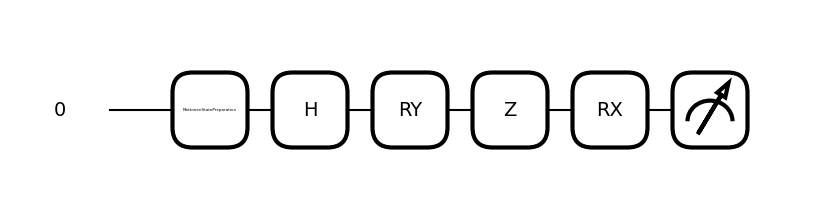

In [6]:
qp.draw_mpl(quiz_function)(0.8, -0.4)

In [8]:
quiz_function(0.8, -0.4)

tensor([0.875, 0.125], requires_grad=True)

## Exercise 1: $Y$-basis measurement

Implement the circuit below, but perform a measurement in the $Y$ basis, 

$$
 \ket{p} = \frac{1}{\sqrt{2}} \ket{0} + \frac{i}{\sqrt{2}}\ket{1}, \quad 
 \ket{m} = \frac{1}{\sqrt{2}} \ket{0} - \frac{i}{\sqrt{2}}\ket{1}.
$$

Plot the outcome probability of $|p\rangle$, as a function of $\theta$. How does $\theta$ affect the measurement outcome probabilities?
 
<img src="fig/exercise-circuit.png" width=300>

In [16]:
dev = qp.device('default.qubit', wires=1)
  
def convert_to_y_basis():
    # YOUR CODE HERE; find a circuit that sends 
    # |0> -> |p> and |1> -> |m>
    qp.Hadamard(0)
    qp.S(0)
    
@qp.qnode(dev)
def circuit_with_y_basis_measurement(theta):  
    # Step 1: run the circuit above
    qp.Hadamard(0)
    qp.RZ(theta, 0)
    # Step 2: measure in the y-basis and return the probabilities 
    # Run convert_to_y_basis backwards
    qp.adjoint(convert_to_y_basis)()
    return qp.probs()

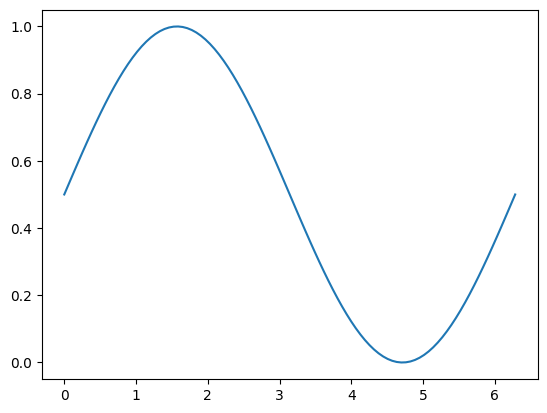

In [17]:
import matplotlib.pyplot as plt

thetas = np.linspace(0, 2*np.pi, 100)
plt.plot(thetas, [circuit_with_y_basis_measurement(t)[0] for t in thetas])

## Exercise 2: One-bit adder

Use a combination of $X$, CNOT, and TOF to create a quantum version of a one-bit adder. Test it in PennyLane on all possible bit values of $a$ and $b$.

<img src="fig/half-adder-blank.png" width=300>

In [ ]:
dev = qp.device("default.qubit", wires=3)

@qp.qnode(dev)
def one_bit_adder(a, b):
    # Step 1: initialize a and b based on input values

    # Step 2: perform the addition to create sum and carry bits

    # Step 3: return a meaningful measurement result
    return